In [ ]:
knitr::opts_chunk$set(echo = TRUE)

In [4]:
library(knitr)
library(haven)
library(dplyr)
library(car)
library(survey)
library(srvyr)


Attaching package: 'srvyr'


The following object is masked from 'package:stats':

    filter




## Read datasets

In [5]:
#Nacist data a z nekterych vybrat jen nektere promenne

#Demographics, RIDAGEYR - vek, RIDEXPRG - pregnant, DMDEDUC2 - education level, RIAGENDR - gender, INDFMPIR - ratio of family income to poverty 
#RIDSTATR - both interview and MEC examination (2 - both, 1 - only interview)
demo_data = read_xpt("./data/DEMO_H.xpt") |> select(SEQN,RIDAGEYR,RIDEXPRG,DMDEDUC2,RIAGENDR,INDFMPIR,WTMEC2YR, SDMVPSU,SDMVSTRA)
#Reproductive health data, RHQ031 - had regular periods in past 12 months, RHQ074 - tried for a yer to become pregnant, RHQ076 - seen DR unable to become pregnant, RHQ131 - ever been pregnant, 
#RHQ160 - how many times have been pregnant, RHQ171 - live birth deliveries, RHD280 - had a hysterectomy, RHQ078 - pelvic infection,RHD180 - age at firts livebirth
rhq_data = read_xpt("./data/RHQ_H.xpt") |> select(SEQN,RHQ031,RHQ074,RHQ076, RHQ131,RHQ160, RHQ171, RHD280, RHQ078, RHD180)
# SEx steroide hormone, LBXTST - testosterone (ng/dL), LBXEXT - estradiol(pg/mL), LBXSHGB (nmol/L), promene koncici na LC (0 - above detection limit, 1 below detection limit)
tst_data = read_xpt("./data/TST_H.xpt")
#Phtalates and plasticizesr metabolites
ssphte_data = read_xpt("./data/SSPHTE_H.xpt")

#Personal care and consumer product chemicals and metabolites
ephpp_data = read_xpt("./data/EPHPP_H.xpt")

#phtalates and plasticizers metabolites
phthte_data = read_xpt("./data/PHTHTE_H.xpt")

#alcohol use, ALQ120Q - How often drink alcohol over past 12 months
alq_data = read_xpt("./data/ALQ_H.xpt") |> select(SEQN,ALQ120Q)
#smoking cigarette use, SMQ040 - do you now smoke cigarettes, SMD650 avg cigarettes a day last month
smq_data = read_xpt("./data/SMQ_H.xpt") |> select(SEQN,SMQ040,SMD650)
#medical condition
#mcq_data = read_xpt("./data/MCQ_H.xpt") |> select(SEQN,)
#body measures, BMXBMI - body maxx index
bmx_data = read_xpt("./data/BMX_H.xpt") |> select(SEQN,BMXBMI)



## Merging datasets

In [6]:
#iiner join keep only rows where there is a SEQN match in both datasets
merged_data = inner_join(demo_data, rhq_data, by = "SEQN")
merged_data = inner_join(merged_data, tst_data, by = "SEQN")
merged_data = inner_join(merged_data, ssphte_data, by = "SEQN")
merged_data = inner_join(merged_data, ephpp_data, by = "SEQN")
merged_data = inner_join(merged_data, alq_data, by = "SEQN")
merged_data = inner_join(merged_data, smq_data, by = "SEQN")
merged_data = inner_join(merged_data, bmx_data, by = "SEQN")
merged_data = inner_join(merged_data, phthte_data, by = "SEQN")
nrow(merged_data)
#jedna promena se vyskytuje ve vice datasetech
merged_data <- merged_data[, !grepl("\\.y$", names(merged_data))]
names(merged_data)[names(merged_data) == "URXUCR.x"] <- "URXUCR"
names(merged_data)[names(merged_data) == "WTSB2YR.x"] <- "WTSB2YR"

var_labels <- sapply(merged_data, function(x) attr(x, "label"))
labels_df <- data.frame(
  variable = names(var_labels),
  label = unname(var_labels)
)
print(labels_df)

[1] 917

   variable                                    label
1      SEQN               Respondent sequence number
2  RIDAGEYR                Age in years at screening
3  RIDEXPRG                 Pregnancy status at exam
4  DMDEDUC2             Education level - Adults 20+
5  RIAGENDR                                   Gender
6  INDFMPIR        Ratio of family income to poverty
7  WTMEC2YR       Full sample 2 year MEC exam weight
8   SDMVPSU               Masked variance pseudo-PSU
9  SDMVSTRA           Masked variance pseudo-stratum
10   RHQ031    Had regular periods in past 12 months
11   RHQ074     Tried for a year to become pregnant?
12   RHQ076 Seen a DR b/c unable to become pregnant?
13   RHQ131                      Ever been pregnant?
14   RHQ160       How many times have been pregnant?
15   RHQ171   How many deliveries live birth result?
16   RHD280                      Had a hysterectomy?
17   RHQ078 Ever treated for a pelvic infection/PID?
18   RHD180                  Age at first live

## Remove, based on exclusion, inclusion criteria from the plan

In [7]:
#age between 18 and 45 and female only, not pregnant
clean_data <- merged_data[merged_data$RIDAGEYR >= 18 & merged_data$RIDAGEYR <= 50 & merged_data$RIAGENDR == 2 & merged_data$RIDEXPRG == 2,]
nrow(clean_data)
#extreme urinary creatine values

clean_data <- clean_data[clean_data$URXUCR<300,]

#missing key covariates -> R si NaN values odstraní automaticky pri vytvareni modelu ?

#urinary chemicals measurement and MEC examination
clean_data <- clean_data[clean_data$WTSSBH2Y>0 & clean_data$WTSB2YR>0 & clean_data$WTMEC2YR>0,]
nrow(clean_data)

#at least one detectable urinary chemical measurement (ze vsech chemikalii v EPHPP a SSPHTE)
all_vars <- union(union(names(ssphte_data), names(ephpp_data)),names(phthte_data))
exclude_vars <- c( "SEQN","WTSSBH2Y","WTSB2YR" )
edc_vars <- setdiff(all_vars, exclude_vars)
length(edc_vars)
data_1 <- clean_data[
  rowSums(!is.na(clean_data[, edc_vars])) >= 1, #alespon jedna hodnota ze vsech merenych chemikalii neni Nan (missing)
]
# at least one detectable hormone measurement (not missing - nan)
horm_vars <- c("LBXSHBG","LBXEST","LBXTST")
data_1 <- data_1[
  rowSums(!is.na(data_1[, horm_vars])) >= 1, #alespon jedna hodnota ze vsech hormonu neni nan
]

nrow(data_1)

[1] 460

[1] 448

[1] 55

[1] 324

## Survey design object -> to work with the weights
NHANES: You must use the weight of the smallest subpopulation that includes all the variables you want to include in your analysis.
Z tech mensich souboru obsahují speciální vahy jenom ty chemikálie (EPHPP a SSPHTE a PHTHTE). EPHPP a PHTHTE maji stejne (WTSB2YR) a SSPHTE ma jiné (WTSSBH2Y). Nevim ktera z nich by se mela pouzit, ale nejmensi je dataset SSPHTE.

In [8]:
# v ukazkach pak na vsechny upravy pouzivaji uz jenom survey desing objekt -> vytvorit z celych dat a znovu stejne profiltrovat
data_w <- svydesign(id = ~SDMVPSU, strata= ~SDMVSTRA, weight=~WTSB2YR,   nest=TRUE, data=merged_data)

obj_cleaned <- data_w |>
  subset(
    RIDAGEYR >= 18 &
    RIDAGEYR <= 50 &
    RIAGENDR == 2 &
    RIDEXPRG == 2 &
    URXUCR < 300 &
    WTSSBH2Y > 0 &
    WTSB2YR > 0 &
    WTMEC2YR > 0 &
    rowSums(!is.na(as.data.frame(data_w$variables[, edc_vars]))) >= 1 &
    rowSums(!is.na(as.data.frame(data_w$variables[, horm_vars]))) >= 1
  )
nrow(obj_cleaned$variables)
summary(obj_cleaned)
#vytvoreny survey objekt porad obsahuje sloupce s vahama z vetsich datasetu -> pri vytvareni modelu upravit a nebrat je v uvahu

[1] 324

Stratified 1 - level Cluster Sampling design (with replacement)
With (30) clusters.
subset(data_w, RIDAGEYR >= 18 & RIDAGEYR <= 50 & RIAGENDR == 
    2 & RIDEXPRG == 2 & URXUCR < 300 & WTSSBH2Y > 0 & WTSB2YR > 
    0 & WTMEC2YR > 0 & rowSums(!is.na(as.data.frame(data_w$variables[, 
    edc_vars]))) >= 1 & rowSums(!is.na(as.data.frame(data_w$variables[, 
    horm_vars]))) >= 1)
Probabilities:
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
2.515e-06 6.348e-06 1.011e-05 1.047e-05 1.392e-05 3.033e-05 
Stratum Sizes: 
           104 105 106 107 108 109 110 111 112 113 114 115 116 117 118
obs         13  18  20  26  20  21  15  26  29  22  27  23  20  17  27
design.PSU   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2
actual.PSU   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2
Data variables:
 [1] "SEQN"     "RIDAGEYR" "RIDEXPRG" "DMDEDUC2" "RIAGENDR" "INDFMPIR"
 [7] "WTMEC2YR" "SDMVPSU"  "SDMVSTRA" "RHQ031"   "RHQ074"   "RHQ076"  
[13] "RHQ131"   "RHQ160" 

##  Variables statistics

In [9]:
#age
svymean(~RIDAGEYR,obj_cleaned,na.rm = TRUE)



           mean     SE
RIDAGEYR 32.326 0.7096

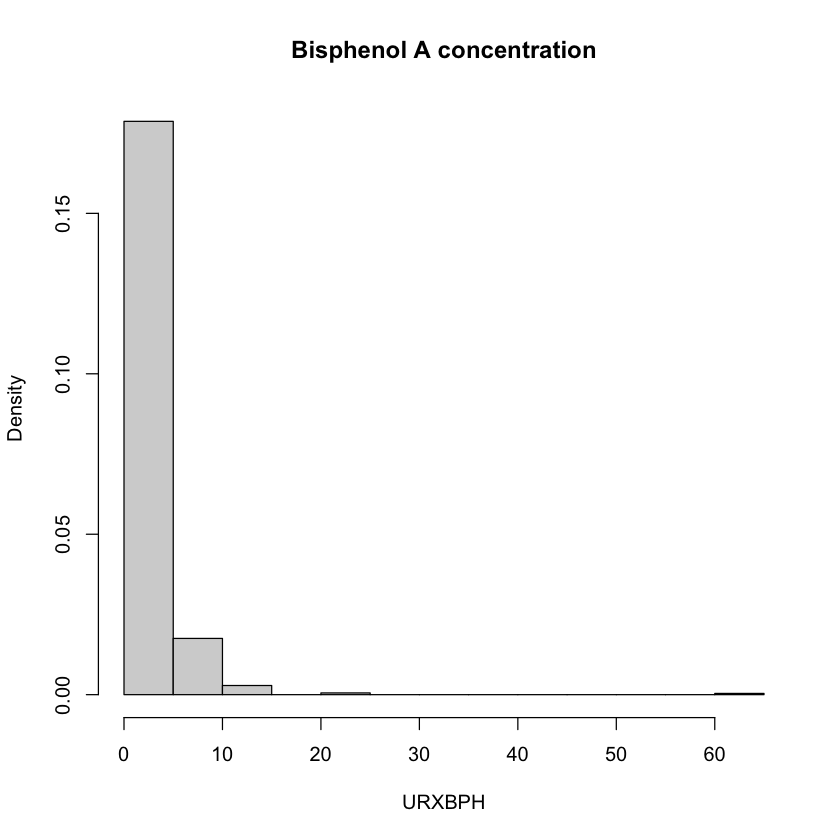

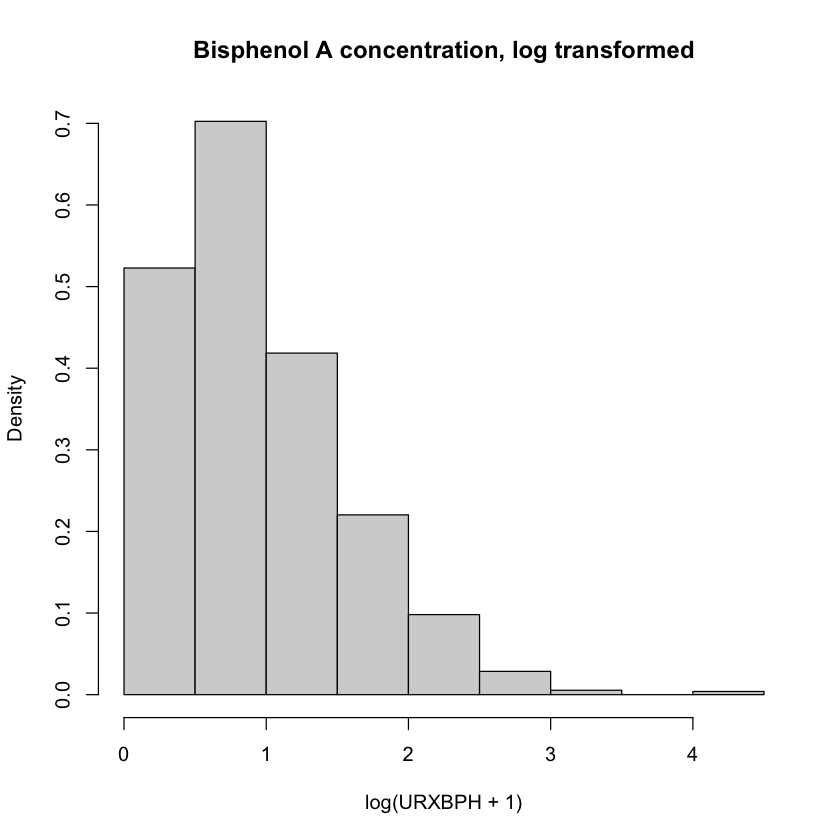

In [10]:
 #visualize
svyhist(~URXBPH, design=obj_cleaned, main="Bisphenol A concentration")

svyhist(~log(URXBPH + 1), design=obj_cleaned, main="Bisphenol A concentration, log transformed")

[1] 22

Warning message in cor(obj_cleaned$variables[, cor_vars], use = "pairwise.complete.obs"):
"the standard deviation is zero"


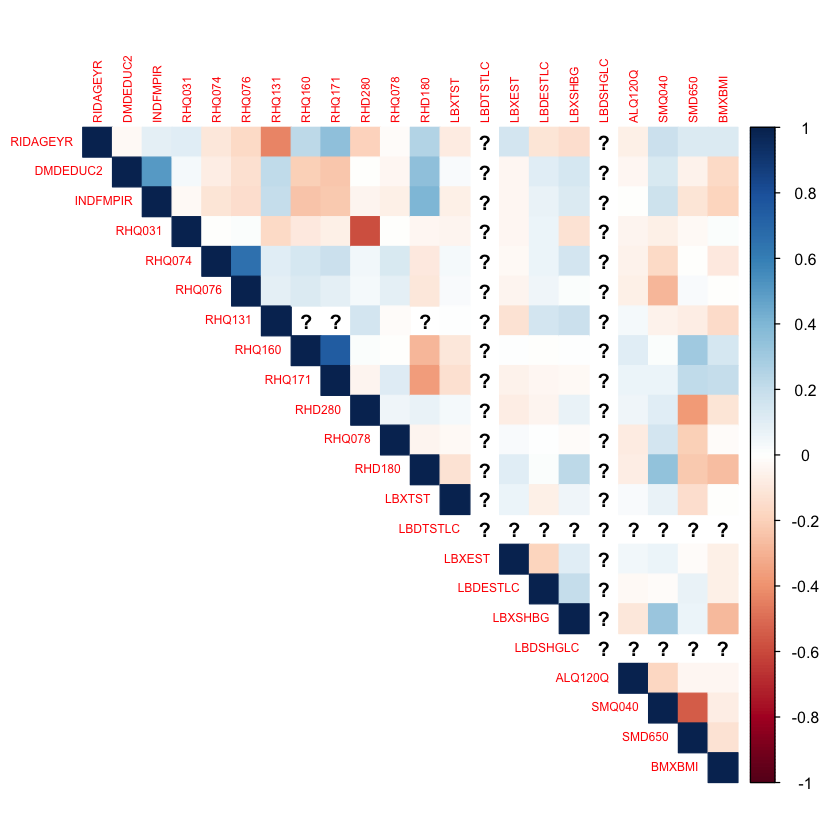

In [11]:
#Correlation matrix - na vsem krome chemikalii, weights a gender a pregnant, protoze to jsou po filtraci vlastne konstantni sloupce pro vsechny stejne
exclude_vars <- c("SEQN","WTMEC2YR", "WTSSBH2Y", "WTSB2YR",edc_vars,"SDMVPSU","SDMVSTRA","RIDEXPRG","RIAGENDR")
cor_vars <- setdiff(names(obj_cleaned$variables), exclude_vars)
length(cor_vars)

cor_matrix <- cor(obj_cleaned$variables[, cor_vars],use = "pairwise.complete.obs")
corrplot::corrplot(cor_matrix,tl.cex = 0.6,method = "color",type = "upper")



In [12]:
#V clanku: Use PCA to deal with collinearity of chemicals -> get fewer independent components. Factors with eigen values higher than 1 were determined as the main components
#pridat dalsi sloupce do datasetu s logtransformovanymi chemikaliemi, edc_vars obsahuje jmena sloupcu vsech chemikalii v datasetu
obj_cleaned$variables[, paste0("log_", edc_vars)] <-log(obj_cleaned$variables[, edc_vars] + 1)
log_edc_vars <- paste0("log_", edc_vars) #log_edc_vars -> jmena vsech log transformovanych chemikalii


#potreba odstranit tuto chemikalii, jinak error: cannot rescale constant/zero column to unit variance, je to comment code (value 0 - at or above detection limit)
del <- c( "log_URDMEPLC" )
log_edc_vars <- setdiff(log_edc_vars,del)


pca_w <- svyprcomp(
  ~ as.matrix(obj_cleaned$variables[, log_edc_vars]),
  design = obj_cleaned,
  center = TRUE,
  scale  = TRUE
)

summary(pca_w)



Importance of components:
                          PC1     PC2     PC3     PC4     PC5    PC6    PC7
Standard deviation     3.6704 2.21698 1.66427 1.60227 1.46470 1.3630 1.2835
Proportion of Variance 0.2495 0.09102 0.05129 0.04754 0.03973 0.0344 0.0305
Cumulative Proportion  0.2495 0.34050 0.39179 0.43933 0.47906 0.5135 0.5440
                           PC8     PC9    PC10    PC11    PC12    PC13   PC14
Standard deviation     1.22780 1.17369 1.16733 1.11589 1.09123 1.07147 1.0236
Proportion of Variance 0.02792 0.02551 0.02523 0.02306 0.02205 0.02126 0.0194
Cumulative Proportion  0.57189 0.59740 0.62263 0.64569 0.66774 0.68900 0.7084
                          PC15    PC16    PC17    PC18    PC19    PC20    PC21
Standard deviation     1.00989 0.97708 0.97394 0.95557 0.94227 0.88011 0.85459
Proportion of Variance 0.01889 0.01768 0.01757 0.01691 0.01644 0.01434 0.01352
Cumulative Proportion  0.72729 0.74497 0.76254 0.77945 0.79589 0.81023 0.82376
                          PC22    PC23    

In [13]:

eigenvalues <- pca_w$sdev^2
prop_var    <- eigenvalues / sum(eigenvalues)
cum_var     <- cumsum(prop_var)

pca_table <- data.frame(
  PC = paste0("PC", seq_along(eigenvalues)),
  Eigenvalue = eigenvalues,
    Proportion_of_variance = prop_var,
  Cumulative_variance = cum_var
)

pca_table


PC,Eigenvalue,Proportion_of_variance,Cumulative_variance
<chr>,<dbl>,<dbl>,<dbl>
PC1,13.47199921,0.2494814668,0.2494815
PC2,4.91501617,0.0910188180,0.3405003
PC3,2.76978822,0.0512923744,0.3917927
PC4,2.56726255,0.0475418991,0.4393346
PC5,2.14535004,0.0397287045,0.4790633
PC6,1.85783366,0.0344043270,0.5134676
PC7,1.64725265,0.0305046786,0.5439723
PC8,1.50748634,0.0279164138,0.5718887
PC9,1.37753841,0.0255099706,0.5973987


In [16]:

# Save the cleaned data frame as RDS (preserves R object structure)
saveRDS(data_1, file = "./data/cleaned_data.rds")

# Save the survey design object as RDS 
saveRDS(obj_cleaned, file = "./data/survey_object_cleaned.rds")



# Save both objects together in one .RData file
save(data_1, obj_cleaned, file = "./data/cleaned_nhanes_data.RData")

In [18]:
#save data labels
write.csv(labels_df, "./data/variable_labels.csv", row.names = FALSE)